In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
df = sns.load_dataset('titanic')


In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


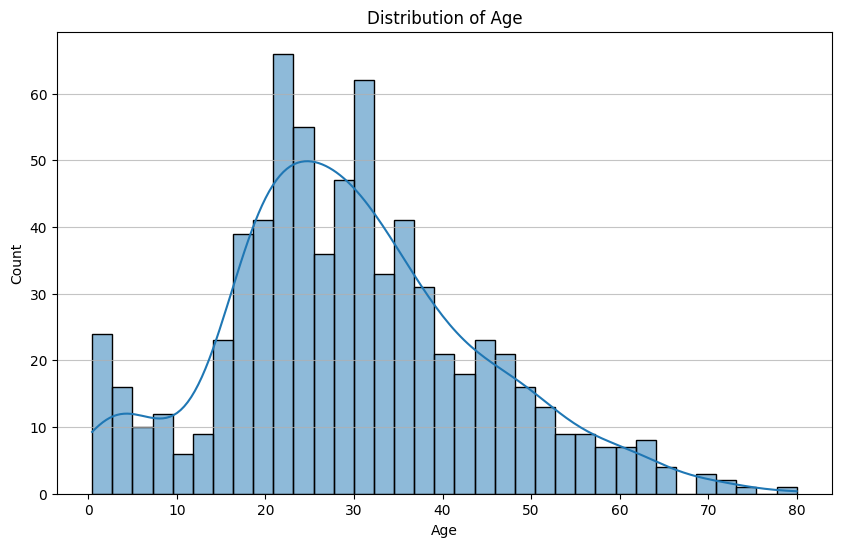

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'].dropna(), kde=True, bins=35)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

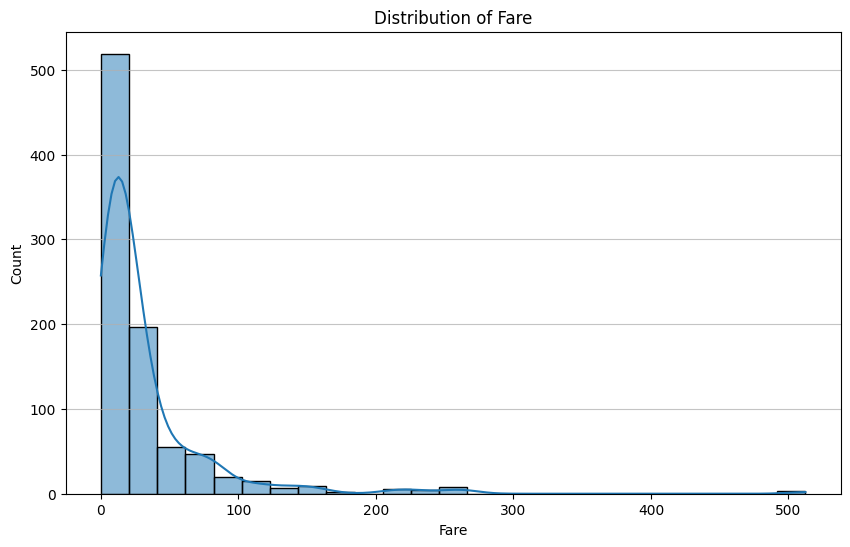

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['fare'].dropna(), kde=True, bins=25)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

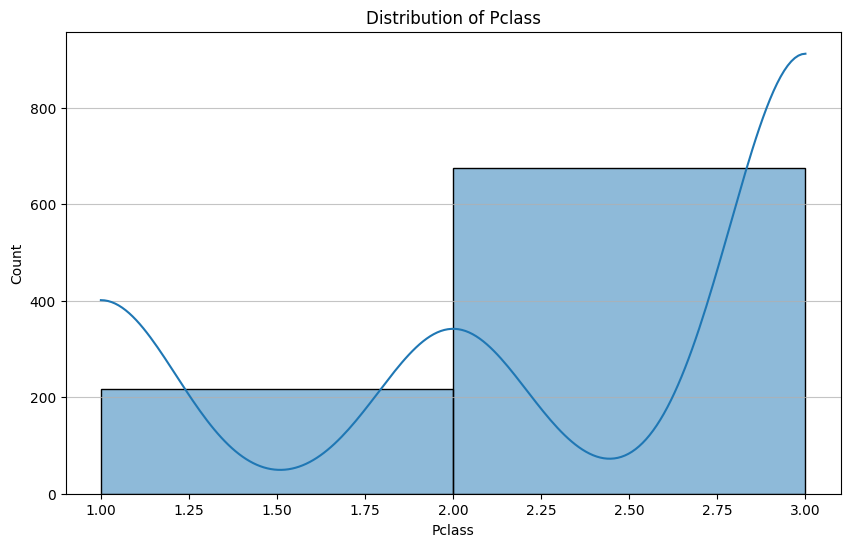

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['pclass'].dropna(), kde=True, bins=2)
plt.title('Distribution of Pclass')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

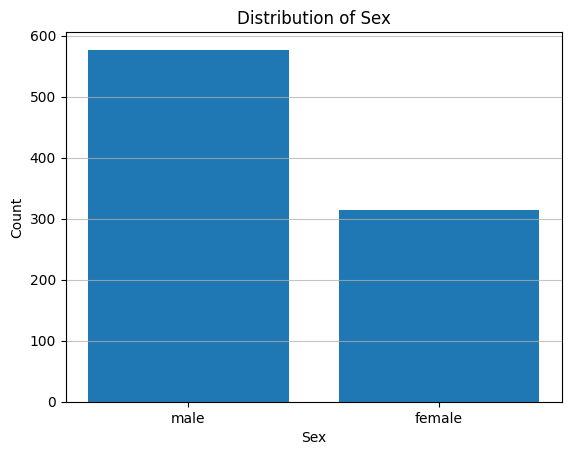

In [ ]:
plt.bar(df['sex'].value_counts().index, df['sex'].value_counts().values)
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

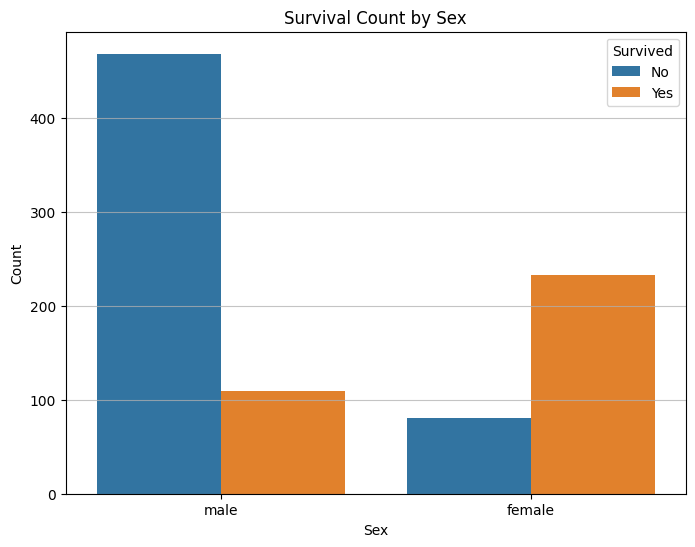

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='sex', hue='survived', data=df)
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
df.corr(numeric_only=True)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


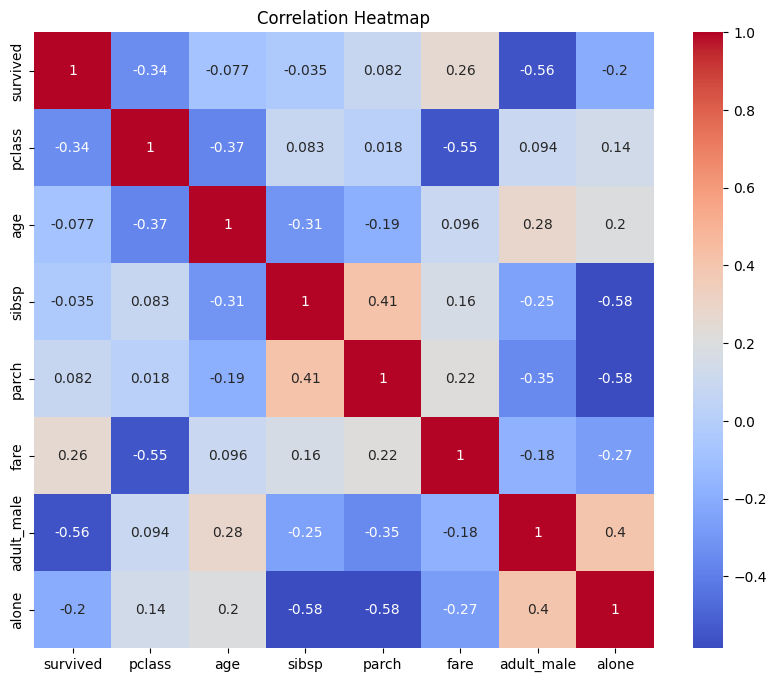

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

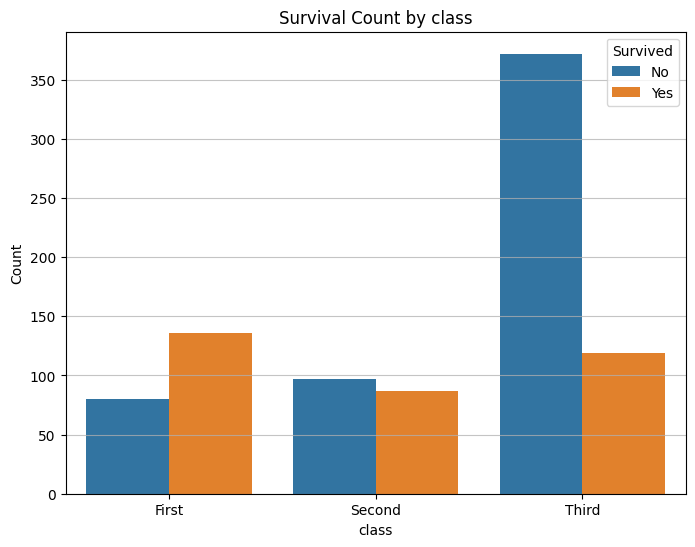

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='class', hue='survived', data=df)
plt.title('Survival Count by class')
plt.xlabel('class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.75)
plt.show()

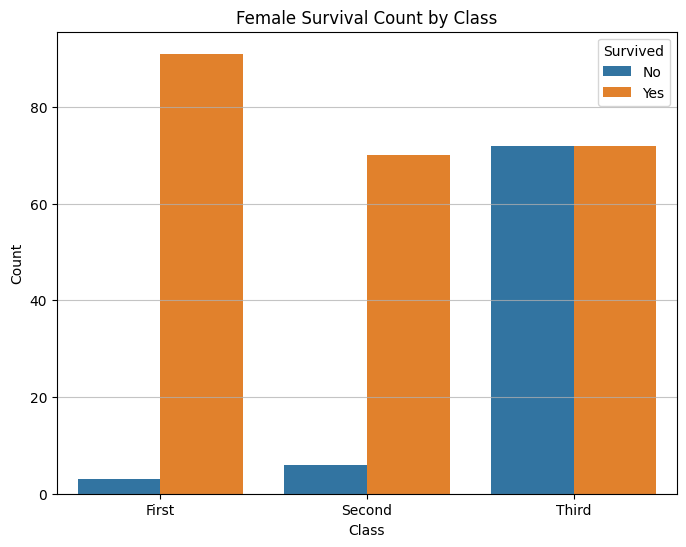

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='class', hue='survived', data=df[df['sex'] == 'female'])
plt.title('Female Survival Count by Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.75)
plt.show()

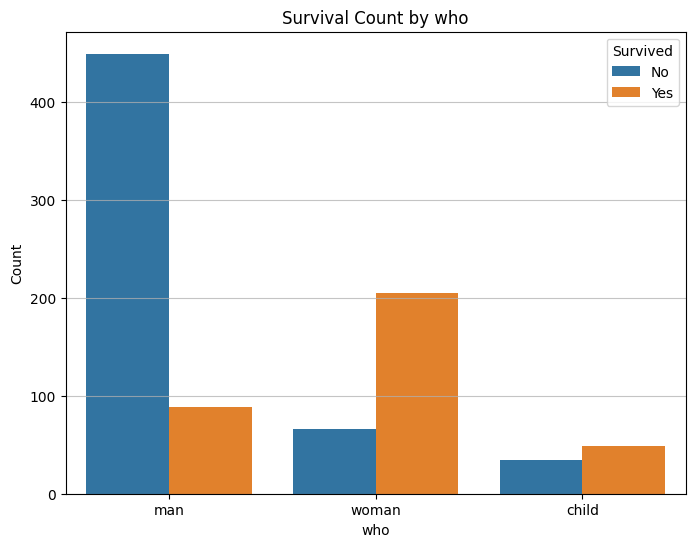

In [ ]:
# Survival Rate by who
plt.figure(figsize=(8, 6))
sns.countplot(x='who', hue='survived', data=df)
plt.title('Survival Count by who')
plt.xlabel('who')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.75)
plt.show()

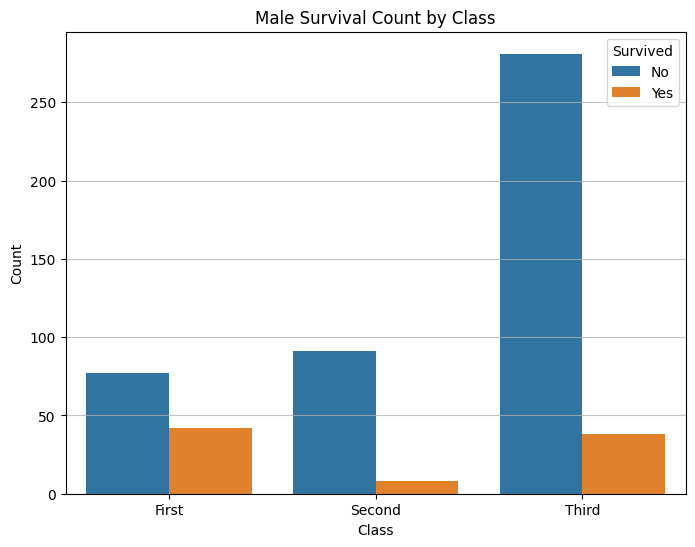

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='class', hue='survived', data=df[df['who'] == 'man'])
plt.title('Male Survival Count by Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.75)
plt.show()

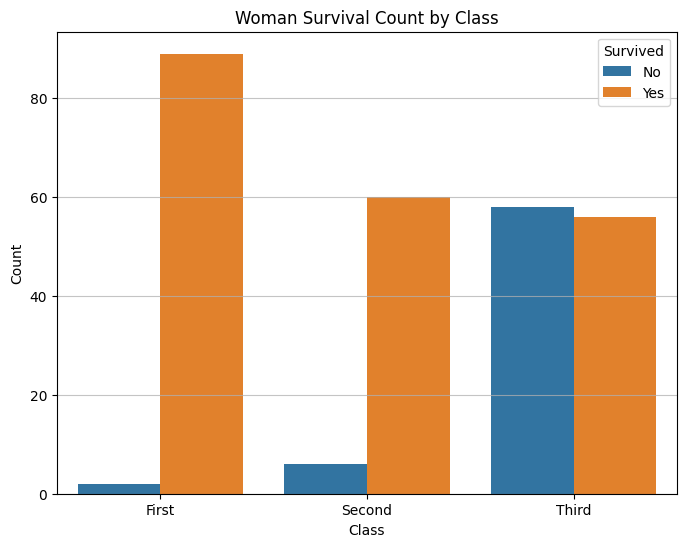

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='class', hue='survived', data=df[df['who'] == 'woman'])
plt.title('Woman Survival Count by Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.75)
plt.show()

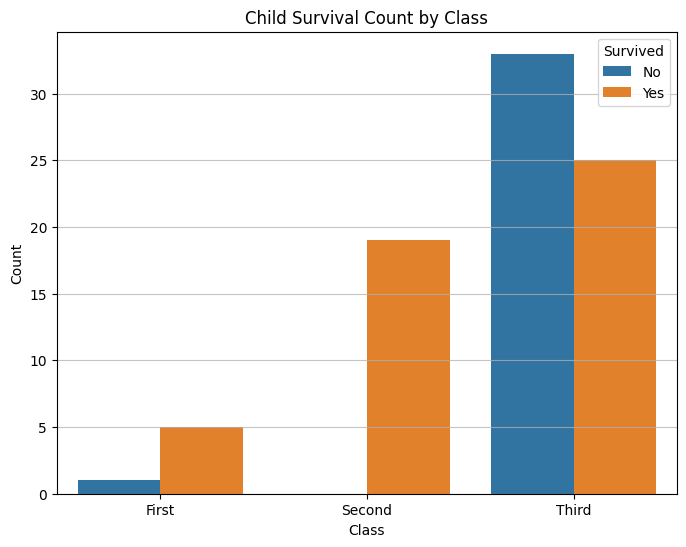

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='class', hue='survived', data=df[df['who'] == 'child'])
plt.title('Child Survival Count by Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.75)
plt.show()

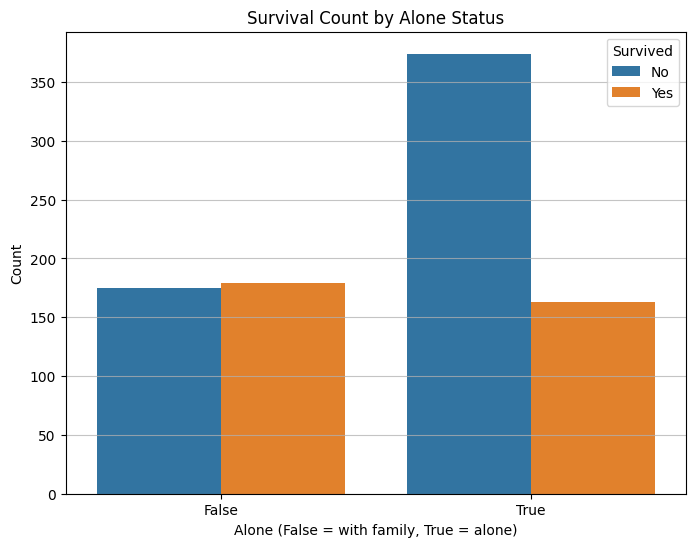

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='alone', hue='survived', data=df)
plt.title('Survival Count by Alone Status')
plt.xlabel('Alone (False = with family, True = alone)')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.75)
plt.show()

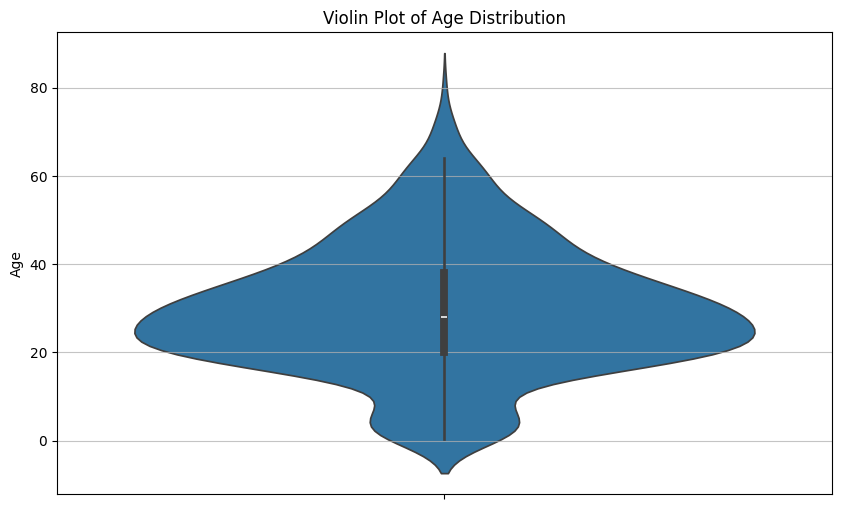

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(y=df['age'].dropna())
plt.title('Violin Plot of Age Distribution')
plt.ylabel('Age')
plt.grid(axis='y', alpha=0.75)
plt.show()

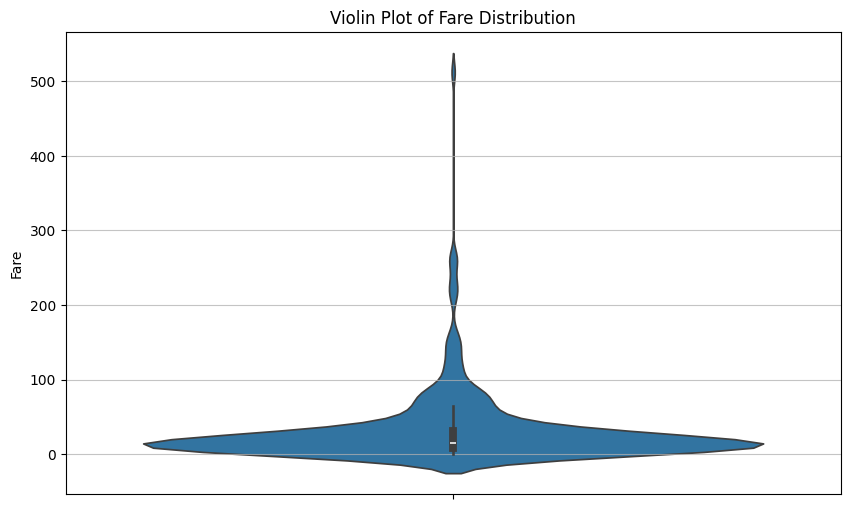

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(y=df['fare'].dropna())
plt.title('Violin Plot of Fare Distribution')
plt.ylabel('Fare')
plt.grid(axis='y', alpha=0.75)
plt.show()

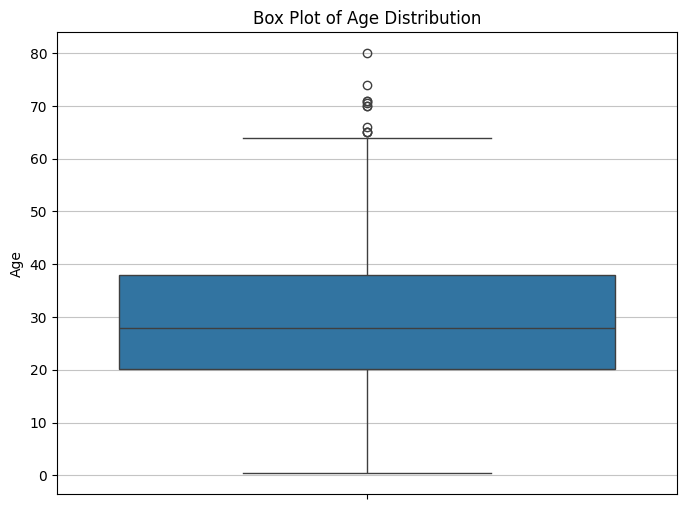

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['age'].dropna())
plt.title('Box Plot of Age Distribution')
plt.ylabel('Age')
plt.grid(axis='y', alpha=0.75)
plt.show()

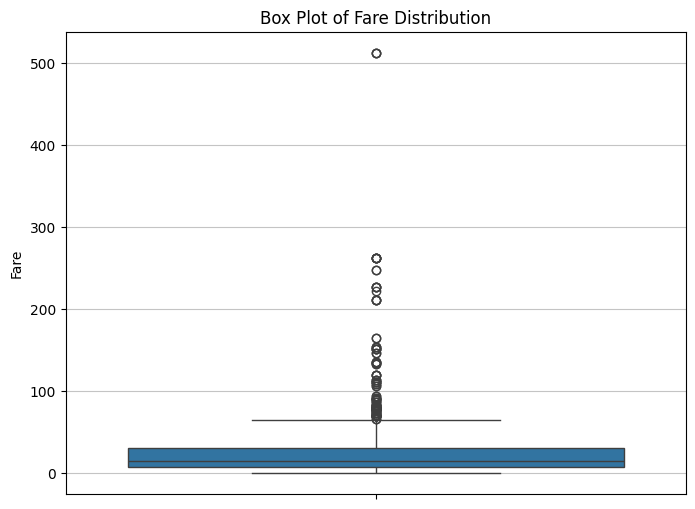

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['fare'].dropna())
plt.title('Box Plot of Fare Distribution')
plt.ylabel('Fare')
plt.grid(axis='y', alpha=0.75)
plt.show()

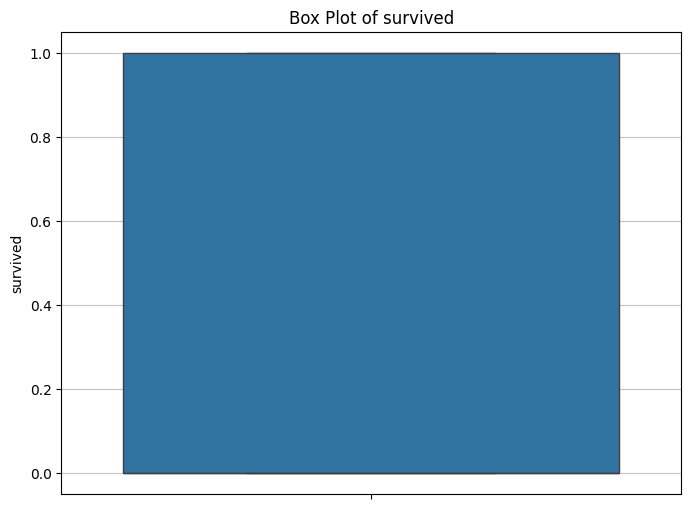

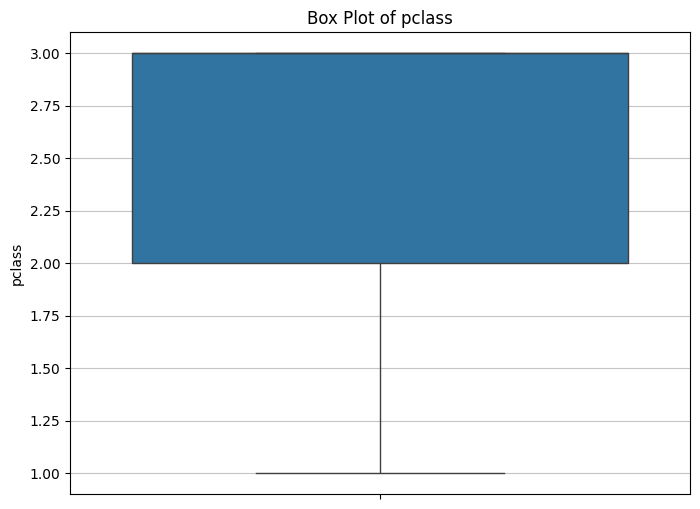

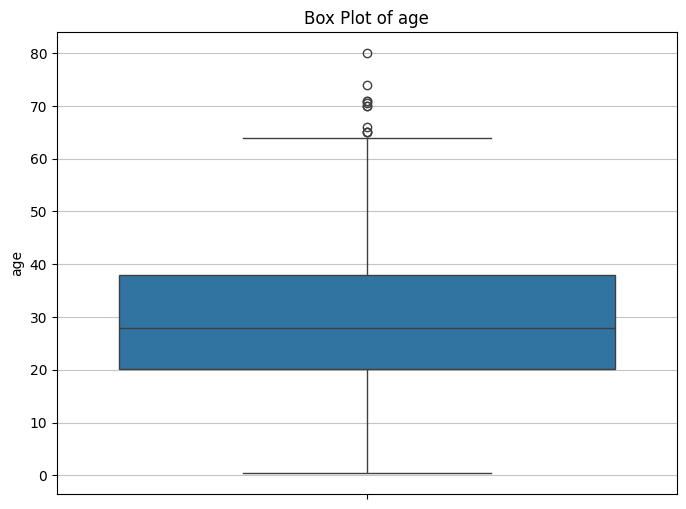

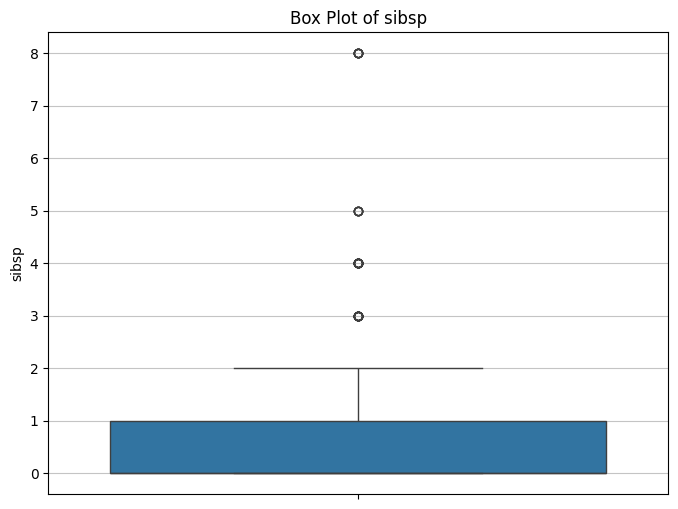

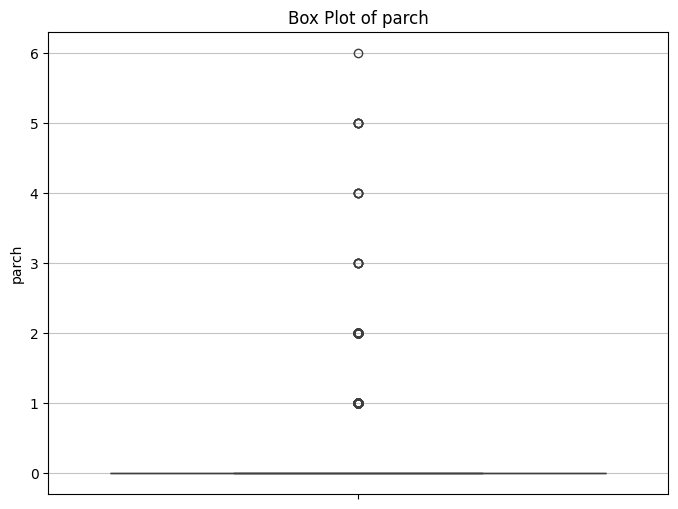

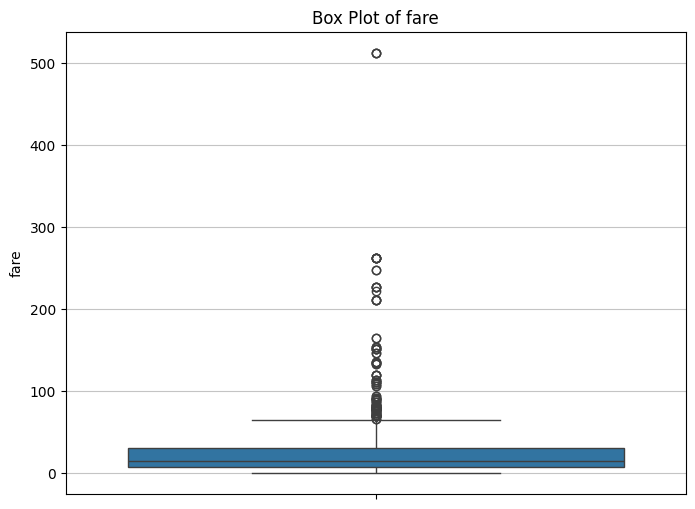

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col].dropna())
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.grid(axis='y', alpha=0.75)
    plt.show()

In [ ]:
X = df.drop(['survived'], axis=1)
y = df['survived']

In [ ]:
X.shape


(891, 14)

In [ ]:
y.shape

(891,)

In [ ]:
X.isna().sum()

,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0
adult_male,0


In [ ]:
X.deck.head(20)

,deck
0,NaN
1,C
2,NaN
3,C
4,NaN
5,NaN
6,E
7,NaN
8,NaN
9,NaN


In [ ]:
X.drop(['deck','alive', 'embarked'],axis=1, inplace=True)

In [ ]:
X

,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alone
0,3,male,22.0,1,0,7.2500,Third,man,True,Southampton,False
1,1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,False
2,3,female,26.0,0,0,7.9250,Third,woman,False,Southampton,True
3,1,female,35.0,1,0,53.1000,First,woman,False,Southampton,False
4,3,male,35.0,0,0,8.0500,Third,man,True,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,Second,man,True,Southampton,True
887,1,female,19.0,0,0,30.0000,First,woman,False,Southampton,True
888,3,female,NaN,1,2,23.4500,Third,woman,False,Southampton,False
889,1,male,26.0,0,0,30.0000,First,man,True,Cherbourg,True


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
imputer_age = SimpleImputer(strategy='mean')
X_train['age'] = imputer_age.fit_transform(X_train[['age']])
X_test['age'] = imputer_age.transform(X_test[['age']])

print('Missing values in X_train after age imputation:')
print(X_train.isna().sum())
print('\nMissing values in X_test after age imputation:')
print(X_test.isna().sum())

Missing values in X_train after age imputation:
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
class          0
who            0
adult_male     0
embark_town    2
alone          0
dtype: int64

Missing values in X_test after age imputation:
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
class          0
who            0
adult_male     0
embark_town    0
alone          0
dtype: int64


In [ ]:
imputer_embark_town = SimpleImputer(strategy='most_frequent')
X_train['embark_town'] = imputer_embark_town.fit_transform(X_train[['embark_town']]).ravel()
X_test['embark_town'] = imputer_embark_town.transform(X_test[['embark_town']]).ravel()

print('Missing values in X_train after embark_town imputation:')
print(X_train.isna().sum())
print('\nMissing values in X_test after embark_town imputation:')
print(X_test.isna().sum())

Missing values in X_train after embark_town imputation:
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
class          0
who            0
adult_male     0
embark_town    0
alone          0
dtype: int64

Missing values in X_test after embark_town imputation:
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
class          0
who            0
adult_male     0
embark_town    0
alone          0
dtype: int64


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
X_train

,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alone
331,1,male,45.500000,0,0,28.5000,First,man,True,Southampton,True
733,2,male,23.000000,0,0,13.0000,Second,man,True,Southampton,True
382,3,male,32.000000,0,0,7.9250,Third,man,True,Southampton,True
704,3,male,26.000000,1,0,7.8542,Third,man,True,Southampton,False
813,3,female,6.000000,4,2,31.2750,Third,child,False,Southampton,False
...,...,...,...,...,...,...,...,...,...,...,...
106,3,female,21.000000,0,0,7.6500,Third,woman,False,Southampton,True
270,1,male,29.498846,0,0,31.0000,First,man,True,Southampton,True
860,3,male,41.000000,2,0,14.1083,Third,man,True,Southampton,False
435,1,female,14.000000,1,2,120.0000,First,child,False,Southampton,False


In [ ]:
# # Scale and encode the Numeric and Categorical column
# numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
# categorical_cols = X_train.select_dtypes(include=['object']).columns

# numeric_transformer = StandardScaler()
# categorical_transformer = OneHotEncoder(handle_unknown='ignore')

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
# pipe = Pipeline([
#     ('scaler', StandardScaler(numeric_cols=True)),
#     ('knn', KNeighborsClassifier())
# ])

In [ ]:
# param_grid = {
#     'knn__n_neighbors': [3, 5, 7, 9,11, 13, 15, 17, 19],
#     'knn__weights': ['uniform', 'distance'],
#     'knn__metric': ['euclidean', 'manhattan', 'minkowski']
# }



In [ ]:
# grid_search = GridSearchCV(pipe, param_grid, cv=10, scoring='accuracy',
#                            n_jobs=-1, verbose=0)
# grid_search.fit(X_train, y_train)

In [ ]:
# print('GridSearchCV Results:')
# print(f'  Best Parameters : {grid_search.best_params_}')
# print(f'  Best CV Score   : {grid_search.best_score_:.4f}')

# best_model = grid_search.best_estimator_
# test_acc   = best_model.score(X_train, y_train)
# print(f'  Test Accuracy   : {test_acc:.4f}')